# Module imports

In [1]:
from pathlib import Path
import jax.numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.widgets import Slider

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal
import gwfast.network as network
from gwfast.lensing_utils import \
    compute_lensed_angles_approx, \
    PML_time_delay_magnification, \
    dLGridGlob, zGridGlob, einstein_angle

from pycbc.psd import *
from pycbc.filter import match
from pycbc.types.frequencyseries import FrequencySeries

from tqdm import tqdm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

/Users/yuranzhang/gwfast_AGN/gwfast_moddd/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# Function definitions

## AGN lensing with the option to turn off Doppler or angular effects

In [2]:
def get_agn_lensed_params(unlensed_parameters, partial='full'):
    plus_image_params = unlensed_parameters.copy()
    minus_image_params = unlensed_parameters.copy()

    lensed_params = compute_lensed_angles_approx(unlensed_parameters)

    # Environemental effects (orbit-induced redshift and gravitational redshift) can be modeled as
    # changes in effective chirp mass and effective luminosity distance
    # https://arxiv.org/abs/2310.16025 Eqs. 4&5
    plus_redshift_factor = (1 + lensed_params['z_rel_p']) * (1 + lensed_params['z_grav'])
    minus_redshift_factor = (1 + lensed_params['z_rel_m']) * (1 + lensed_params['z_grav'])

    plus_image_params['dL'] /= lensed_params['sqrt_mu_p']
    plus_image_params['dL'] *= (1 + lensed_params['z_rel_p']) * plus_redshift_factor
    minus_image_params['dL'] /= lensed_params['sqrt_mu_m']
    minus_image_params['dL'] *= (1 + lensed_params['z_rel_m']) * minus_redshift_factor
    minus_image_params['tcoal'] += lensed_params['delta_time'] / DAY_TO_SEC  # days
    if partial == 'full':
        plus_image_params['iota'] = lensed_params['iota_p']
        plus_image_params['phase'] = lensed_params['phase_p']
        plus_image_params['Mc'] *= plus_redshift_factor
        minus_image_params['iota'] = lensed_params['iota_m']
        minus_image_params['phase'] = lensed_params['phase_m']
        minus_image_params['Mc'] *= minus_redshift_factor
    elif partial == 'no doppler': # only angular changes
        plus_image_params['iota'] = lensed_params['iota_p']
        plus_image_params['phase'] = lensed_params['phase_p']
        minus_image_params['iota'] = lensed_params['iota_m']
        minus_image_params['phase'] = lensed_params['phase_m']
    elif partial == 'no angular': # only effective mass changes
        plus_image_params['Mc'] *= plus_redshift_factor
        minus_image_params['Mc'] *= minus_redshift_factor
    elif partial == 'no agn':
        pass

    return plus_image_params, minus_image_params

## `convert_y_to_src_pos` definition

In [3]:
def convert_y_to_src_pos(y, R_orbit, rs=1):
    # Convert source position from units of Einstein radius to units of R_orbit
    # Returns a 2D grid of src_pos with shape (len(y), len(R_orbit))
    Dls_min = (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs # for rs=1, this is in units of R_S
    theta_E = np.sqrt(2 * Dls_min) # Einstein radius in units of R_S
    src_pos = np.outer(y, theta_E / R_orbit)
    return src_pos

## Mismatch without maximizing over phase

In [4]:
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch(frequencies, h1, h2, psd):
    # Ranges from 0 to 1
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

# def mismatch(frequencies, h1, h2, psd):
#     # Ranges from 0 to 2
#     return 1 - inner_product(frequencies, h1, h2, psd) / np.sqrt(inner_product(frequencies, h1, h1, psd) * inner_product(frequencies, h2, h2, psd))

# Detector setup

In [5]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

# H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
# L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
# V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
# HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_BBH = BasicGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


# Parameter injection

In [6]:
# Define a benchmark event
n = 100
shape = (n, n)
events = {
    'Mc': 30, 'eta': 0.24, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.5,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.full(shape, val).astype(np.float64) for key, val in events.items()}

# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n**2), (-1, n, n))

# Sample parameter space
R_orbit_array = np.geomspace(10, 1e4, n)
Mc_array = np.linspace(10, 100, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
y_array = np.linspace(0.1, 2, n) # in Einstein radii

# Fix y in Einstein radii for the first two event copies
y_const_array = np.full(n, 0.5) # in Einstein radii
src_pos_grid = convert_y_to_src_pos(y_const_array, R_orbit_array)

# Prepare injections
R_orbit_mesh, Mc_mesh = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = R_orbit_mesh
events_copy_1['Mc'] = Mc_mesh
# events_copy_1['src_pos'] = src_pos_grid

R_orbit_mesh, M_lz_mesh = np.meshgrid(R_orbit_array, M_lz_array, indexing='xy')
events_copy_2 = events.copy()
events_copy_2['R_orbit'] = R_orbit_mesh
events_copy_2['M_lz'] = M_lz_mesh
# events_copy_2['src_pos'] = src_pos_grid

R_orbit_mesh, _ = np.meshgrid(R_orbit_array, y_array, indexing='xy')
src_pos_grid_3 = convert_y_to_src_pos(y_array, R_orbit_array)
events_copy_3 = events.copy()
events_copy_3['R_orbit'] = R_orbit_mesh
events_copy_3['src_pos'] = src_pos_grid_3

# Get lensed parameters with no second order AGN lensing effects
plus_params_noAGN_1, minus_params_noAGN_1 = get_agn_lensed_params(events_copy_1, partial='no agn')
plus_params_noAGN_2, minus_params_noAGN_2 = get_agn_lensed_params(events_copy_2, partial='no agn')
plus_params_noAGN_3, minus_params_noAGN_3 = get_agn_lensed_params(events_copy_3, partial='no agn')
# Get lensed parameters with only angular changes, no Doppler
plus_params_noDop_1, minus_params_noDop_1 = get_agn_lensed_params(events_copy_1, partial='no doppler')
plus_params_noDop_2, minus_params_noDop_2 = get_agn_lensed_params(events_copy_2, partial='no doppler')
plus_params_noDop_3, minus_params_noDop_3 = get_agn_lensed_params(events_copy_3, partial='no doppler')
# Get lensed parameters with only Doppler, no angular changes
plus_params_noAng_1, minus_params_noAng_1 = get_agn_lensed_params(events_copy_1, partial='no angular')
plus_params_noAng_2, minus_params_noAng_2 = get_agn_lensed_params(events_copy_2, partial='no angular')
plus_params_noAng_3, minus_params_noAng_3 = get_agn_lensed_params(events_copy_3, partial='no angular')

# Generate strains from L1
FD_strain_noAGN_1 = L1_BBH.GWstrain(freq_grid, plus_params_noAGN_1) + L1_BBH.GWstrain(freq_grid, minus_params_noAGN_1)
FD_strain_noAGN_2 = L1_BBH.GWstrain(freq_grid, plus_params_noAGN_2) + L1_BBH.GWstrain(freq_grid, minus_params_noAGN_2)
FD_strain_noAGN_3 = L1_BBH.GWstrain(freq_grid, plus_params_noAGN_3) + L1_BBH.GWstrain(freq_grid, minus_params_noAGN_3)

FD_strain_noDop_1 = L1_BBH.GWstrain(freq_grid, plus_params_noDop_1) + L1_BBH.GWstrain(freq_grid, minus_params_noDop_1)
FD_strain_noDop_2 = L1_BBH.GWstrain(freq_grid, plus_params_noDop_2) + L1_BBH.GWstrain(freq_grid, minus_params_noDop_2)
FD_strain_noDop_3 = L1_BBH.GWstrain(freq_grid, plus_params_noDop_3) + L1_BBH.GWstrain(freq_grid, minus_params_noDop_3)

FD_strain_noAng_1 = L1_BBH.GWstrain(freq_grid, plus_params_noAng_1) + L1_BBH.GWstrain(freq_grid, minus_params_noAng_1)
FD_strain_noAng_2 = L1_BBH.GWstrain(freq_grid, plus_params_noAng_2) + L1_BBH.GWstrain(freq_grid, minus_params_noAng_2)
FD_strain_noAng_3 = L1_BBH.GWstrain(freq_grid, plus_params_noAng_3) + L1_BBH.GWstrain(freq_grid, minus_params_noAng_3)

# Compute mismatch

## Traditional mismatch

In [7]:
# mismatch_noDop_1_array = np.zeros((n, n))
# mismatch_noDop_2_array = np.zeros((n, n))
# mismatch_noDop_3_array = np.zeros((n, n))
# mismatch_noAng_1_array = np.zeros((n, n))
# mismatch_noAng_2_array = np.zeros((n, n))
# mismatch_noAng_3_array = np.zeros((n, n))

# for i in tqdm(range(n)):
#     for j in range(n):
#         freq_array_temp = freq_grid[:, i, j]
#         delta_f = freq_array_temp[1]-freq_array_temp[0]

#         normal_temp_1 = FD_strain_noAGN_1[:, i, j]
#         normal_temp_2 = FD_strain_noAGN_2[:, i, j]
#         normal_temp_3 = FD_strain_noAGN_3[:, i, j]

#         AGN_noDop_temp_1 = FD_strain_noDop_1[:, i, j]
#         AGN_noDop_temp_2 = FD_strain_noDop_2[:, i, j]
#         AGN_noDop_temp_3 = FD_strain_noDop_3[:, i, j]

#         AGN_noAng_temp_1 = FD_strain_noAng_1[:, i, j]
#         AGN_noAng_temp_2 = FD_strain_noAng_2[:, i, j]
#         AGN_noAng_temp_3 = FD_strain_noAng_3[:, i, j]

#         psd_FS = FrequencySeries(np.asarray(psd_interp), delta_f=delta_f, epoch=0)
#         normal_lensed_FS_1 = FrequencySeries(np.asarray(normal_temp_1), delta_f=delta_f, epoch=0)
#         normal_lensed_FS_2 = FrequencySeries(np.asarray(normal_temp_2), delta_f=delta_f, epoch=0)
#         normal_lensed_FS_3 = FrequencySeries(np.asarray(normal_temp_3), delta_f=delta_f, epoch=0)
#         AGN_noDop_lensed_FS_1 = FrequencySeries(np.asarray(AGN_noDop_temp_1), delta_f=delta_f, epoch=0)
#         AGN_noDop_lensed_FS_2 = FrequencySeries(np.asarray(AGN_noDop_temp_2), delta_f=delta_f, epoch=0)
#         AGN_noDop_lensed_FS_3 = FrequencySeries(np.asarray(AGN_noDop_temp_3), delta_f=delta_f, epoch=0)
#         AGN_noAng_lensed_FS_1 = FrequencySeries(np.asarray(AGN_noAng_temp_1), delta_f=delta_f, epoch=0)
#         AGN_noAng_lensed_FS_2 = FrequencySeries(np.asarray(AGN_noAng_temp_2), delta_f=delta_f, epoch=0)
#         AGN_noAng_lensed_FS_3 = FrequencySeries(np.asarray(AGN_noAng_temp_3), delta_f=delta_f, epoch=0)

#         # Compute match
#         match_noDop_1, _ = match(normal_lensed_FS_1, 
#                         AGN_noDop_lensed_FS_1, 
#                         psd=psd_FS, 
#                         low_frequency_cutoff=minimum_frequency)
#         match_noDop_2, _ = match(AGN_noDop_lensed_FS_2, 
#                         normal_lensed_FS_2, 
#                         psd=psd_FS, 
#                         low_frequency_cutoff=minimum_frequency)
#         match_noDop_3, _ = match(AGN_noDop_lensed_FS_3, 
#                         normal_lensed_FS_3, 
#                         psd=psd_FS, 
#                         low_frequency_cutoff=minimum_frequency)
#         match_noAng_1, _ = match(normal_lensed_FS_1, 
#                         AGN_noAng_lensed_FS_1, 
#                         psd=psd_FS, 
#                         low_frequency_cutoff=minimum_frequency)
#         match_noAng_2, _ = match(AGN_noAng_lensed_FS_2, 
#                         normal_lensed_FS_2, 
#                         psd=psd_FS, 
#                         low_frequency_cutoff=minimum_frequency)
#         match_noAng_3, _ = match(AGN_noAng_lensed_FS_3, 
#                         normal_lensed_FS_3, 
#                         psd=psd_FS, 
#                         low_frequency_cutoff=minimum_frequency)

#         mismatch_noDop_1_array[i, j] = np.full_like(match_noDop_1, 1) - match_noDop_1
#         mismatch_noDop_2_array[i, j] = np.full_like(match_noDop_2, 1) - match_noDop_2
#         mismatch_noDop_3_array[i, j] = np.full_like(match_noDop_3, 1) - match_noDop_3
        
#         mismatch_noAng_1_array[i, j] = np.full_like(match_noAng_1, 1) - match_noAng_1
#         mismatch_noAng_2_array[i, j] = np.full_like(match_noAng_2, 1) - match_noAng_2
#         mismatch_noAng_3_array[i, j] = np.full_like(match_noAng_3, 1) - match_noAng_3

## Mismatch without maximizing over phase

In [8]:
mismatch_mod_noDop_1 = mismatch(freq_grid, FD_strain_noAGN_1, FD_strain_noDop_1, psd_interp_grid)
mismatch_mod_noDop_2 = mismatch(freq_grid, FD_strain_noAGN_2, FD_strain_noDop_2, psd_interp_grid)
mismatch_mod_noDop_3 = mismatch(freq_grid, FD_strain_noAGN_3, FD_strain_noDop_3, psd_interp_grid)

mismatch_mod_noAng_1 = mismatch(freq_grid, FD_strain_noAGN_1, FD_strain_noAng_1, psd_interp_grid)
mismatch_mod_noAng_2 = mismatch(freq_grid, FD_strain_noAGN_2, FD_strain_noAng_2, psd_interp_grid)
mismatch_mod_noAng_3 = mismatch(freq_grid, FD_strain_noAGN_3, FD_strain_noAng_3, psd_interp_grid)

# Plot mismatch

Text(0, 0.5, '$y\\equiv\\beta/\\theta_E$')

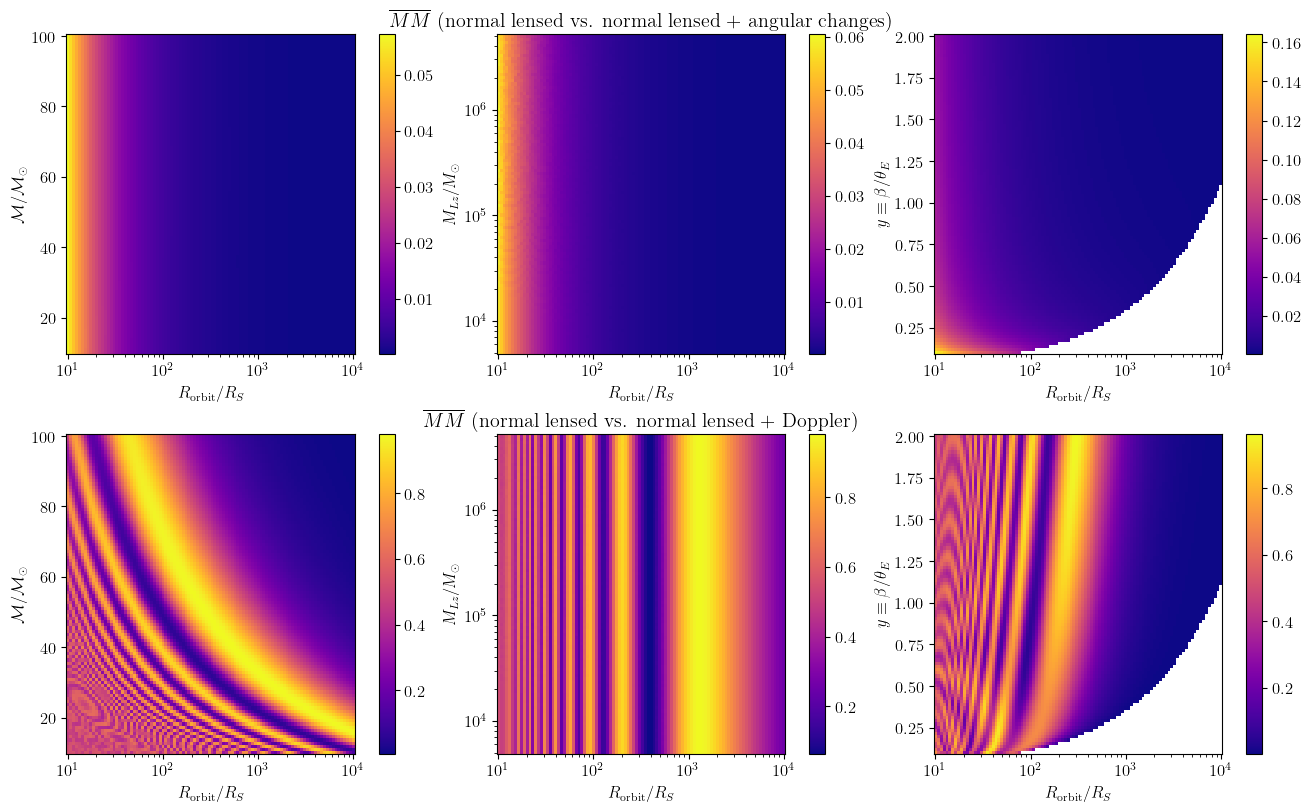

In [22]:
fig, axs = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
cmap = plt.cm.plasma

ax = axs[0,0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_mod_noDop_1, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$\cal M/M_\odot$')

ax = axs[0,1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_mod_noDop_2, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(r'$\overline{MM}$ (normal lensed vs. normal lensed + angular changes)')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$M_{Lz}/M_\odot$')

ax = axs[0,2]
im = ax.pcolormesh(R_orbit_array, y_array, mismatch_mod_noDop_3, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

ax = axs[1, 0]
im = ax.pcolormesh(R_orbit_array, Mc_array, mismatch_mod_noAng_1, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$\cal M/M_\odot$')

ax = axs[1, 1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, mismatch_mod_noAng_2, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(r'$\overline{MM}$ (normal lensed vs. normal lensed + Doppler)')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$M_{Lz}/M_\odot$')

ax = axs[1, 2]
im = ax.pcolormesh(R_orbit_array, y_array, mismatch_mod_noAng_3, cmap=cmap)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$y\equiv\beta/\theta_E$')

Text(0, 0.5, '$\\cal M_+/\\cal M_-$')

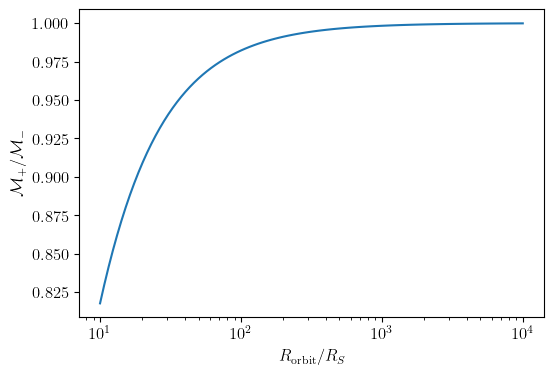

In [21]:
Mc_plus = plus_params_noAng_2['Mc'][0, :]
Mc_minus = minus_params_noAng_2['Mc'][0, :]
Mc_ratio = Mc_plus / Mc_minus

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(R_orbit_array, Mc_ratio)
ax.set_xscale('log')
ax.set_xlabel(r'$R_\mathrm{orbit}/R_S$')
ax.set_ylabel(r'$\cal M_+/\cal M_-$')